# k-means e escolha de k

**Tema:** Aprendizado Não Supervisionado › Clustering

Este notebook implementa o algoritmo de Lloyd do zero e confirma contra
`sklearn.cluster.KMeans`, reproduz o exemplo numérico do `teoria.pdf`,
mede o efeito da inicialização (aleatória vs. k-means++), mostra o
estrago de não padronizar as features, compara os critérios de escolha de
$k$ e termina com o teste mais importante do módulo: k-means aplicado a
dados **sem estrutura nenhuma**.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score)
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(51)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
CORES = np.array([AZUL, VERMELHO, VERDE, ROXO, AMBAR, "#5A5A5A", "#2A9D8F", "#E76F51"])
print("pronto")

pronto


## 1. O algoritmo de Lloyd do zero

Dois passos alternados: atribuir cada ponto ao centróide mais próximo e
mover cada centróide para a média do seu grupo. A classe abaixo guarda o
histórico da inércia para podermos ver que ela **nunca sobe**.

In [2]:
class KMeansDoZero:
    def __init__(self, k, max_iter=100, semente=0):
        self.k = k
        self.max_iter = max_iter
        self.semente = semente

    def fit(self, X, centroides_iniciais=None):
        gerador = np.random.default_rng(self.semente)
        if centroides_iniciais is None:
            centroides_iniciais = X[gerador.choice(len(X), self.k, replace=False)]
        c = np.asarray(centroides_iniciais, dtype=float).copy()
        self.historico_inercia_ = []
        for it in range(self.max_iter):
            dist2 = ((X[:, None, :] - c[None, :, :]) ** 2).sum(axis=2)
            rotulos = dist2.argmin(axis=1)
            novos = np.array([X[rotulos == j].mean(axis=0) if np.any(rotulos == j) else c[j]
                              for j in range(self.k)])
            inercia = ((X - novos[rotulos]) ** 2).sum()
            self.historico_inercia_.append(inercia)
            if np.allclose(novos, c):
                break
            c = novos
        self.centroides_, self.rotulos_, self.inercia_, self.n_iter_ = c, rotulos, inercia, it + 1
        return self


X, y_verdadeiro = make_blobs(n_samples=900, centers=4, cluster_std=1.2, random_state=7)
nosso = KMeansDoZero(k=4, semente=3).fit(X)
sk = KMeans(n_clusters=4, init=nosso.centroides_, n_init=1).fit(X)  # parte do nosso resultado
print(f"inércia (do zero): {nosso.inercia_:.2f} em {nosso.n_iter_} iterações")
print(f"inércia (sklearn, partindo dos mesmos centróides): {sk.inertia_:.2f}")
print("histórico da inércia:", np.round(nosso.historico_inercia_, 1))

inércia (do zero): 22901.70 em 6 iterações
inércia (sklearn, partindo dos mesmos centróides): 22901.70
histórico da inércia: [26069.2 22975.6 22901.8 22901.8 22901.7 22901.7]


## 2. O exemplo numérico do `teoria.pdf`

Pontos $[1, 2, 4, 7, 9, 10]$, $k=2$, centróides iniciais 1 e 4. O texto
calculou à mão: inércia 21,5 após a iteração 1 e 9,33 na convergência.

In [3]:
x1d = np.array([1, 2, 4, 7, 9, 10], dtype=float).reshape(-1, 1)
exemplo = KMeansDoZero(k=2).fit(x1d, centroides_iniciais=[[1.0], [4.0]])
print("inércia a cada iteração:", np.round(exemplo.historico_inercia_, 3))
print("centróides finais:", exemplo.centroides_.ravel().round(3))
print("grupos finais:", exemplo.rotulos_)

inércia a cada iteração: [21.5    9.333  9.333]
centróides finais: [2.333 8.667]
grupos finais: [0 0 0 1 1 1]


## 3. Inicialização: aleatória vs. k-means++

Rodamos o k-means 200 vezes com `n_init=1` (uma única inicialização) em
dados com 8 grupos, com cada estratégia de inicialização. Um mínimo local
ruim aparece como inércia bem acima da melhor encontrada.

    random: 72% das execuções ficaram >5% acima da melhor inércia
 k-means++: 29% das execuções ficaram >5% acima da melhor inércia


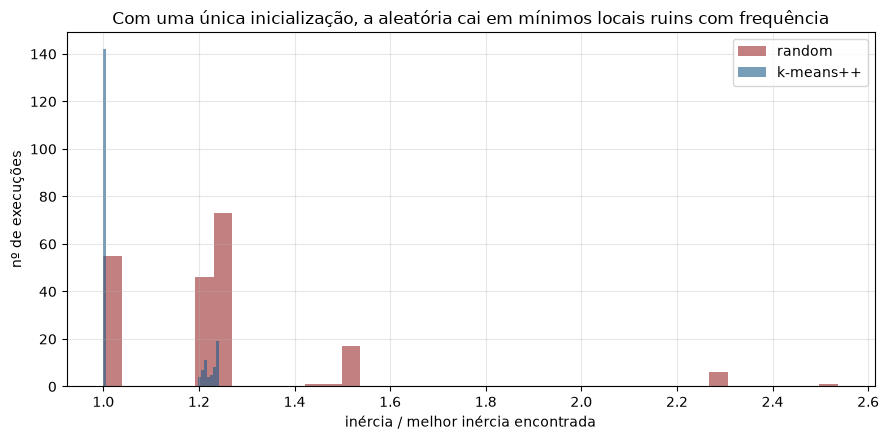

In [4]:
X8, _ = make_blobs(n_samples=2000, centers=8, cluster_std=0.9, random_state=2)
resultados = {}
for init in ["random", "k-means++"]:
    resultados[init] = np.array([
        KMeans(n_clusters=8, init=init, n_init=1, random_state=s).fit(X8).inertia_
        for s in range(200)])
melhor = min(r.min() for r in resultados.values())

fig, ax = plt.subplots(figsize=(9, 4.5))
for (init, r), cor in zip(resultados.items(), [VERMELHO, AZUL]):
    ax.hist(r / melhor, bins=40, alpha=0.6, color=cor, label=init)
    ruins = (r > 1.05 * melhor).mean()
    print(f"{init:>10s}: {ruins:.0%} das execuções ficaram >5% acima da melhor inércia")
ax.set_xlabel("inércia / melhor inércia encontrada")
ax.set_ylabel("nº de execuções")
ax.set_title("Com uma única inicialização, a aleatória cai em mínimos locais ruins com frequência")
ax.legend(); plt.tight_layout(); plt.show()

**Leitura esperada:** a inicialização aleatória produz uma cauda longa de
execuções presas em mínimos locais; k-means++ concentra quase tudo perto
do melhor valor. Por isso o padrão do `scikit-learn` combina k-means++
**e** várias inicializações (`n_init`).

## 4. Escala: o agrupamento pela coluna de maior variância

Dois grupos reais de clientes que diferem em **idade** (jovens vs.
maduros), com renda sem relação com o grupo. Sem padronizar, a renda — em
reais, com variância gigante — decide sozinha.

concordância com o grupo real — sem padronizar: 51.0%
concordância com o grupo real — padronizado   : 100.0%


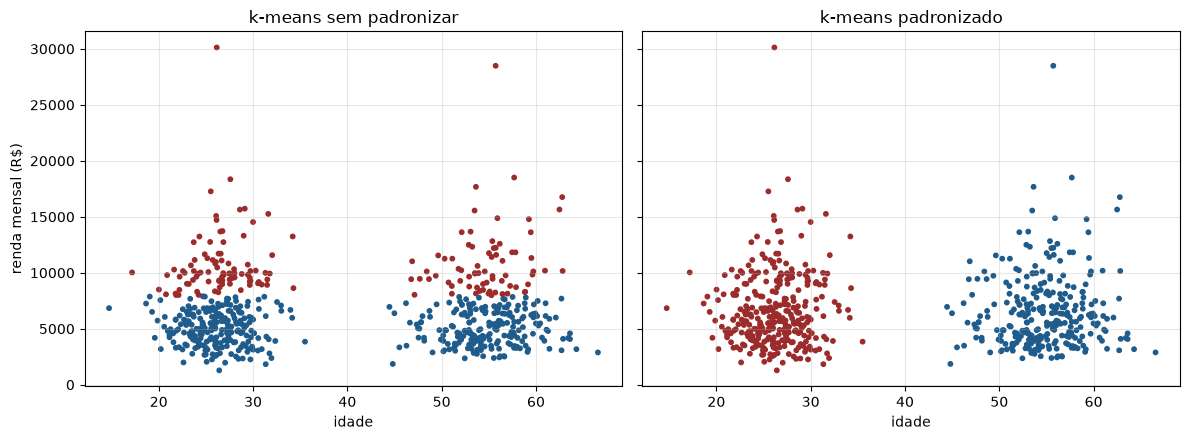

In [5]:
n = 600
grupo = rng.integers(0, 2, n)
idade = np.where(grupo == 0, rng.normal(26, 3, n), rng.normal(55, 4, n))
renda = rng.lognormal(np.log(6000), 0.45, n)
clientes = np.column_stack([idade, renda])

rot_bruto = KMeans(2, n_init=10, random_state=0).fit_predict(clientes)
rot_padron = KMeans(2, n_init=10, random_state=0).fit_predict(
    StandardScaler().fit_transform(clientes))

def concordancia(a, b):
    return max((a == b).mean(), (a != b).mean())  # rótulos podem vir trocados

print(f"concordância com o grupo real — sem padronizar: {concordancia(rot_bruto, grupo):.1%}")
print(f"concordância com o grupo real — padronizado   : {concordancia(rot_padron, grupo):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, rot, tit in zip(axes, [rot_bruto, rot_padron], ["sem padronizar", "padronizado"]):
    ax.scatter(idade, renda, s=10, c=CORES[rot])
    ax.set_xlabel("idade"); ax.set_title(f"k-means {tit}")
axes[0].set_ylabel("renda mensal (R$)")
plt.tight_layout(); plt.show()

Sem padronizar, o k-means corta a base numa linha horizontal de renda —
a separação por idade, que é a estrutura real, é ignorada. É o exemplo
numérico do `teoria.pdf` (clientes A, B e C) em escala de base inteira.

## 5. Escolhendo k: quatro critérios lado a lado

In [6]:
linhas = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    linhas.append({"k": k, "inércia": km.inertia_,
                   "silhueta": silhouette_score(X, km.labels_),
                   "Calinski-Harabasz": calinski_harabasz_score(X, km.labels_),
                   "Davies-Bouldin": davies_bouldin_score(X, km.labels_)})
criterios = pd.DataFrame(linhas).set_index("k")
print(criterios.round(3).to_string())
print(f"\nmelhor k — silhueta: {criterios['silhueta'].idxmax()} | "
      f"CH: {criterios['Calinski-Harabasz'].idxmax()} | "
      f"DB: {criterios['Davies-Bouldin'].idxmin()}  (verdade: 4)")

     inércia  silhueta  Calinski-Harabasz  Davies-Bouldin
k                                                        
2  29225.004     0.571           1195.323           0.817
3   8625.698     0.742           3093.778           0.367
4   2502.083     0.772           7833.375           0.319
5   2281.102     0.648           6458.657           0.670
6   2066.976     0.517           5714.338           0.940
7   1862.890     0.416           5294.032           1.095
8   1652.035     0.314           5127.629           1.217

melhor k — silhueta: 4 | CH: 4 | DB: 4  (verdade: 4)


## 6. O gráfico de silhueta por ponto

A silhueta média esconde a distribuição. O gráfico abaixo mostra a
silhueta de cada ponto, agrupada por cluster: grupos com muitos pontos de
silhueta negativa estão mal definidos.

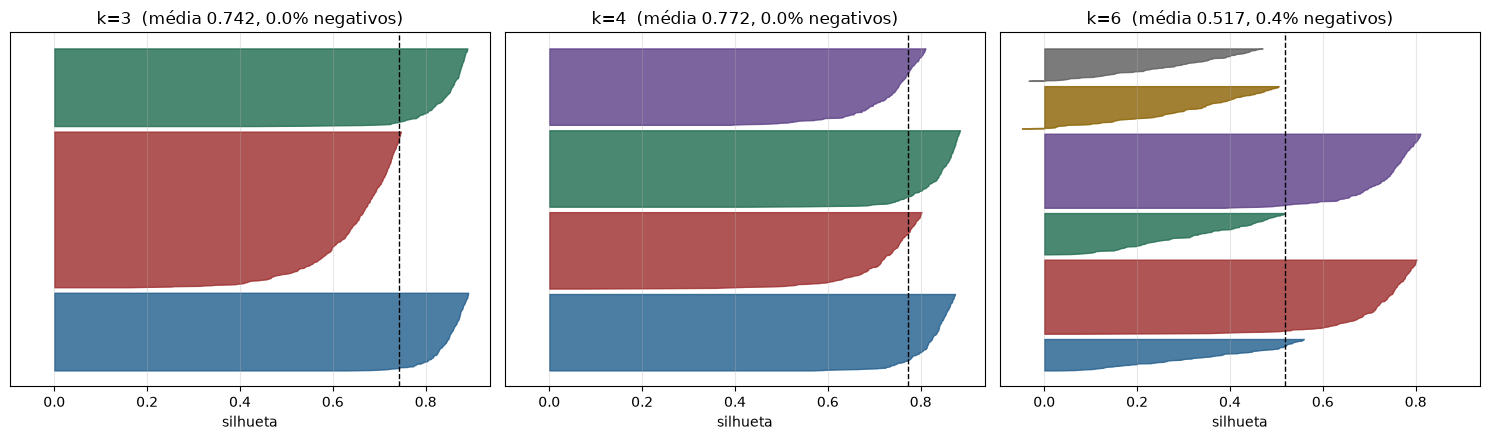

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for ax, k in zip(axes, [3, 4, 6]):
    rot = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)
    s = silhouette_samples(X, rot)
    base = 0
    for j in range(k):
        sj = np.sort(s[rot == j])
        ax.fill_betweenx(np.arange(base, base + len(sj)), 0, sj, color=CORES[j], alpha=0.8)
        base += len(sj) + 15
    ax.axvline(s.mean(), color="black", ls="--", lw=1)
    ax.set_title(f"k={k}  (média {s.mean():.3f}, {np.mean(s < 0):.1%} negativos)")
    ax.set_yticks([]); ax.set_xlabel("silhueta")
plt.tight_layout(); plt.show()

## 7. O teste que todo mundo pula: k-means em ruído puro

Dados **uniformes** num quadrado — não há grupo nenhum. O k-means entrega
5 grupos com centróides e tamanhos perfeitamente "apresentáveis".

tamanhos dos 'grupos': [220 181 196 241 162]
silhueta média no ruído: 0.396
silhueta média nos blobs (k=4): 0.772


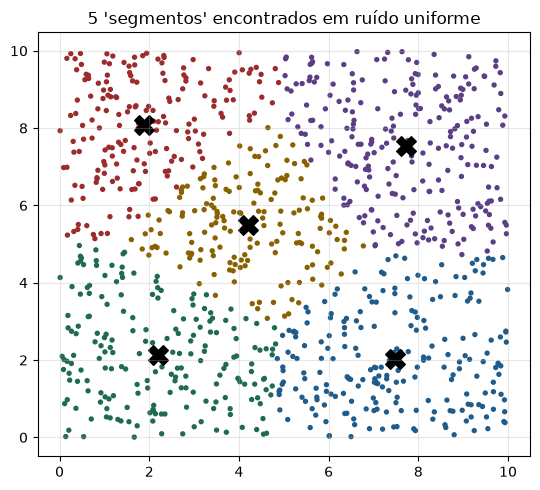

In [8]:
ruido = rng.uniform(0, 10, (1000, 2))
km_ruido = KMeans(n_clusters=5, n_init=10, random_state=0).fit(ruido)
print("tamanhos dos 'grupos':", np.bincount(km_ruido.labels_))
print(f"silhueta média no ruído: {silhouette_score(ruido, km_ruido.labels_):.3f}")
print(f"silhueta média nos blobs (k=4): {criterios.loc[4, 'silhueta']:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(ruido[:, 0], ruido[:, 1], s=8, c=CORES[km_ruido.labels_])
ax.scatter(*km_ruido.cluster_centers_.T, s=200, marker="X", c="black")
ax.set_title("5 'segmentos' encontrados em ruído uniforme")
plt.tight_layout(); plt.show()

**Leitura esperada:** a silhueta no ruído fica bem abaixo da dos blobs,
mas **não é zero** — cortar um quadrado em 5 fatias convexas produz
fatias razoavelmente coesas. Por isso a silhueta sozinha não prova
estrutura: compare sempre com uma referência (dados embaralhados coluna a
coluna, ou uniformes no mesmo intervalo) — a ideia da *gap statistic*.

In [9]:
def silhueta_referencia(X, k, n_ref=5):
    """Silhueta média de k-means em dados uniformes no mesmo retângulo de X."""
    vals = []
    for s in range(n_ref):
        ref = np.random.default_rng(s).uniform(X.min(axis=0), X.max(axis=0), X.shape)
        vals.append(silhouette_score(ref, KMeans(k, n_init=5, random_state=0).fit_predict(ref)))
    return np.mean(vals)

for nome, dados in [("blobs", X), ("ruído", ruido)]:
    real = silhouette_score(dados, KMeans(4, n_init=10, random_state=0).fit_predict(dados))
    ref = silhueta_referencia(dados, 4)
    print(f"{nome:>6s}: silhueta real={real:.3f} | referência uniforme={ref:.3f} | "
          f"diferença={real - ref:+.3f}")

 blobs: silhueta real=0.772 | referência uniforme=0.404 | diferença=+0.369


 ruído: silhueta real=0.415 | referência uniforme=0.408 | diferença=+0.006


## 8. Escala de produção: KMeans vs. MiniBatchKMeans

In [10]:
X_grande, _ = make_blobs(n_samples=200_000, centers=6, n_features=8, random_state=0)
for nome, modelo in [("KMeans", KMeans(6, n_init=3, random_state=0)),
                     ("MiniBatchKMeans", MiniBatchKMeans(6, n_init=3, batch_size=2048,
                                                         random_state=0))]:
    t0 = time.perf_counter()
    modelo.fit(X_grande)
    dt = time.perf_counter() - t0
    print(f"{nome:>16s}: {dt:6.2f}s  inércia={modelo.inertia_:,.0f}")

          KMeans:   0.46s  inércia=1,597,617
 MiniBatchKMeans:   0.07s  inércia=1,598,052


## O que levar deste notebook

- Lloyd alterna atribuição e atualização; a inércia nunca sobe, mas o
  ponto de chegada é um mínimo **local** que depende da inicialização.
- k-means++ e `n_init` são as defesas contra mínimos locais ruins.
- Sem padronização, o agrupamento é decidido pela coluna de maior escala.
- Os critérios de escolha de $k$ costumam concordar quando a estrutura é
  clara; quando discordam, é sinal de estrutura fraca ou ambígua.
- k-means sempre devolve grupos. Compare com uma referência sem estrutura
  antes de acreditar neles.

→ Próximo: **Hierárquico e DBSCAN**, dois algoritmos com definições de
grupo completamente diferentes.